In [2]:
# Core Libraries
import cudf  # GPU-accelerated dataframe
import cupy as cp  # GPU-accelerated numerical computing
import numpy as np  # Numerical computing
import pandas as pd  # Fallback for CPU operations
import seaborn as sns

# Data Processing
from cuml.preprocessing import MinMaxScaler  # GPU-accelerated scaling
from sklearn.model_selection import train_test_split  # Fallback for data splitting



# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
jagung_df = pd.read_csv('/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga Jagung_2025.csv', parse_dates=['Tanggal'], skipinitialspace=True)
jagung_df['Komoditi']='Jagung'
kacang_df =pd.read_csv('/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga kacang_2025.csv', parse_dates=['Tanggal'], skipinitialspace=True)
kacang_df['Komoditi']='Kacang Hijau'
medium_df =pd.read_csv('/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga medium_2025.csv', parse_dates=['Tanggal'], skipinitialspace=True)
medium_df['Komoditi']='Beras Medium'
premium_df =pd.read_csv('/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga premium_2025.csv', parse_dates=['Tanggal'], skipinitialspace=True)
premium_df['Komoditi']='Beras Premium'

In [4]:
jagung_df

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Komoditi
0,2024-01-01,4383.5938,4538.5127,47858.547,73.485700,385550.34,Monday,January,2024,Jagung
1,2024-01-02,4350.7188,4526.6074,49136.990,73.297195,391489.12,Tuesday,January,2024,Jagung
2,2024-01-03,4302.6410,4498.6875,51100.758,72.998470,402269.84,Wednesday,January,2024,Jagung
3,2024-01-04,4235.2744,4459.0093,53555.490,72.642830,415956.22,Thursday,January,2024,Jagung
4,2024-01-05,4159.5493,4415.5894,56329.434,72.275620,430842.12,Friday,January,2024,Jagung
...,...,...,...,...,...,...,...,...,...,...
726,2025-12-27,3792.8310,4257.8926,83470.790,70.438800,562803.70,Saturday,December,2025,Jagung
727,2025-12-28,3801.5806,4260.3867,84126.050,70.461530,567550.06,Sunday,December,2025,Jagung
728,2025-12-29,3804.3723,4262.9995,84624.234,70.469340,570946.70,Monday,December,2025,Jagung
729,2025-12-30,3798.7822,4264.2640,84604.055,70.456370,570618.60,Tuesday,December,2025,Jagung


In [5]:
kacang_df


,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Komoditi
0,2024-01-01,13019.738,16285.3545,245.41069,2.225980,24.224161,Monday,January,2024,Kacang Hijau
1,2024-01-02,13032.947,16086.2070,98.52529,0.518692,191.752840,Tuesday,January,2024,Kacang Hijau
2,2024-01-03,13085.943,15678.4890,-273.16348,-0.907397,50.480713,Wednesday,January,2024,Kacang Hijau
3,2024-01-04,13059.252,15522.0950,-368.13855,-1.040717,-98.671890,Thursday,January,2024,Kacang Hijau
4,2024-01-05,13053.565,15446.7180,-352.96014,-1.022770,-195.241600,Friday,January,2024,Kacang Hijau
...,...,...,...,...,...,...,...,...,...,...
726,2025-12-27,12902.655,17446.8000,-376.87280,-1.621946,-281.969500,Saturday,December,2025,Kacang Hijau
727,2025-12-28,12892.994,17502.3730,-347.09050,-1.517339,-272.309720,Sunday,December,2025,Kacang Hijau
728,2025-12-29,12885.177,17573.9770,-327.81064,-1.417665,-274.524870,Monday,December,2025,Kacang Hijau
729,2025-12-30,12882.515,17621.3980,-313.53967,-1.377143,-279.447400,Tuesday,December,2025,Kacang Hijau


In [6]:
medium_df

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Komoditi
0,2024-01-01,9395.222,9053.4130,25821.752,55.381374,151008.16,Monday,January,2024,Beras Medium
1,2024-01-02,9394.985,8950.3410,26585.658,55.381252,159075.45,Tuesday,January,2024,Beras Medium
2,2024-01-03,9403.047,8909.4375,27244.602,55.401707,164512.03,Wednesday,January,2024,Beras Medium
3,2024-01-04,9417.994,8907.2440,27767.893,55.417606,167603.56,Thursday,January,2024,Beras Medium
4,2024-01-05,9424.257,8928.1920,27885.732,55.408460,166091.44,Friday,January,2024,Beras Medium
...,...,...,...,...,...,...,...,...,...,...
726,2025-12-27,9396.593,10612.2500,32237.814,55.348780,162979.58,Saturday,December,2025,Beras Medium
727,2025-12-28,9435.542,10792.7440,32734.965,55.373188,165222.78,Sunday,December,2025,Beras Medium
728,2025-12-29,9461.355,10886.7030,32980.934,55.397686,166840.55,Monday,December,2025,Beras Medium
729,2025-12-30,9441.841,10825.0200,32779.460,55.382843,166351.44,Tuesday,December,2025,Beras Medium


In [7]:
premium_df

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Komoditi
0,2024-01-01,10304.973,11705.168,26819.111,55.246930,139726.67,Monday,January,2024,Beras Premium
1,2024-01-02,10257.425,11614.534,26653.293,55.245914,140572.27,Tuesday,January,2024,Beras Premium
2,2024-01-03,10209.408,11524.829,26502.717,55.233950,140917.02,Wednesday,January,2024,Beras Premium
3,2024-01-04,10172.837,11460.848,26466.766,55.224190,141530.55,Thursday,January,2024,Beras Premium
4,2024-01-05,10149.466,11423.055,26586.840,55.222984,142930.78,Friday,January,2024,Beras Premium
...,...,...,...,...,...,...,...,...,...,...
726,2025-12-27,10145.298,11487.648,31188.320,55.457058,177389.66,Saturday,December,2025,Beras Premium
727,2025-12-28,10151.721,11496.717,31421.555,55.464977,178529.84,Sunday,December,2025,Beras Premium
728,2025-12-29,10156.052,11502.443,31631.955,55.470450,179644.12,Monday,December,2025,Beras Premium
729,2025-12-30,10154.617,11499.316,31655.361,55.469830,179843.22,Tuesday,December,2025,Beras Premium


In [8]:
df_x1=pd.concat([jagung_df, kacang_df], ignore_index=True)
df_x2=pd.concat([medium_df, premium_df], ignore_index=True)

In [9]:
df_x1

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Komoditi
0,2024-01-01,4383.5938,4538.5127,47858.54700,73.485700,385550.34000,Monday,January,2024,Jagung
1,2024-01-02,4350.7188,4526.6074,49136.99000,73.297195,391489.12000,Tuesday,January,2024,Jagung
2,2024-01-03,4302.6410,4498.6875,51100.75800,72.998470,402269.84000,Wednesday,January,2024,Jagung
3,2024-01-04,4235.2744,4459.0093,53555.49000,72.642830,415956.22000,Thursday,January,2024,Jagung
4,2024-01-05,4159.5493,4415.5894,56329.43400,72.275620,430842.12000,Friday,January,2024,Jagung
...,...,...,...,...,...,...,...,...,...,...
1457,2025-12-27,12902.6550,17446.8000,-376.87280,-1.621946,-281.96950,Saturday,December,2025,Kacang Hijau
1458,2025-12-28,12892.9940,17502.3730,-347.09050,-1.517339,-272.30972,Sunday,December,2025,Kacang Hijau
1459,2025-12-29,12885.1770,17573.9770,-327.81064,-1.417665,-274.52487,Monday,December,2025,Kacang Hijau
1460,2025-12-30,12882.5150,17621.3980,-313.53967,-1.377143,-279.44740,Tuesday,December,2025,Kacang Hijau


In [10]:
df_x2

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Komoditi
0,2024-01-01,9395.222,9053.4130,25821.752,55.381374,151008.16,Monday,January,2024,Beras Medium
1,2024-01-02,9394.985,8950.3410,26585.658,55.381252,159075.45,Tuesday,January,2024,Beras Medium
2,2024-01-03,9403.047,8909.4375,27244.602,55.401707,164512.03,Wednesday,January,2024,Beras Medium
3,2024-01-04,9417.994,8907.2440,27767.893,55.417606,167603.56,Thursday,January,2024,Beras Medium
4,2024-01-05,9424.257,8928.1920,27885.732,55.408460,166091.44,Friday,January,2024,Beras Medium
...,...,...,...,...,...,...,...,...,...,...
1457,2025-12-27,10145.298,11487.6480,31188.320,55.457058,177389.66,Saturday,December,2025,Beras Premium
1458,2025-12-28,10151.721,11496.7170,31421.555,55.464977,178529.84,Sunday,December,2025,Beras Premium
1459,2025-12-29,10156.052,11502.4430,31631.955,55.470450,179644.12,Monday,December,2025,Beras Premium
1460,2025-12-30,10154.617,11499.3160,31655.361,55.469830,179843.22,Tuesday,December,2025,Beras Premium


In [11]:
df_x=pd.concat([df_x1, df_x2], ignore_index=True)

In [12]:
df_x

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Komoditi
0,2024-01-01,4383.5938,4538.5127,47858.547,73.485700,385550.34,Monday,January,2024,Jagung
1,2024-01-02,4350.7188,4526.6074,49136.990,73.297195,391489.12,Tuesday,January,2024,Jagung
2,2024-01-03,4302.6410,4498.6875,51100.758,72.998470,402269.84,Wednesday,January,2024,Jagung
3,2024-01-04,4235.2744,4459.0093,53555.490,72.642830,415956.22,Thursday,January,2024,Jagung
4,2024-01-05,4159.5493,4415.5894,56329.434,72.275620,430842.12,Friday,January,2024,Jagung
...,...,...,...,...,...,...,...,...,...,...
2919,2025-12-27,10145.2980,11487.6480,31188.320,55.457058,177389.66,Saturday,December,2025,Beras Premium
2920,2025-12-28,10151.7210,11496.7170,31421.555,55.464977,178529.84,Sunday,December,2025,Beras Premium
2921,2025-12-29,10156.0520,11502.4430,31631.955,55.470450,179644.12,Monday,December,2025,Beras Premium
2922,2025-12-30,10154.6170,11499.3160,31655.361,55.469830,179843.22,Tuesday,December,2025,Beras Premium


In [13]:
'''hasil_prediksi_2025_all='/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga 2025 all.csv'
df_x.to_csv(hasil_prediksi_2025_all, index=False)
print(f"DataFrame prediksi berhasil disimpan ke '{hasil_prediksi_2025_all}'")'''

'hasil_prediksi_2025_all=\'/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga 2025 all.csv\'\ndf_x.to_csv(hasil_prediksi_2025_all, index=False)\nprint(f"DataFrame prediksi berhasil disimpan ke \'{hasil_prediksi_2025_all}\'")'

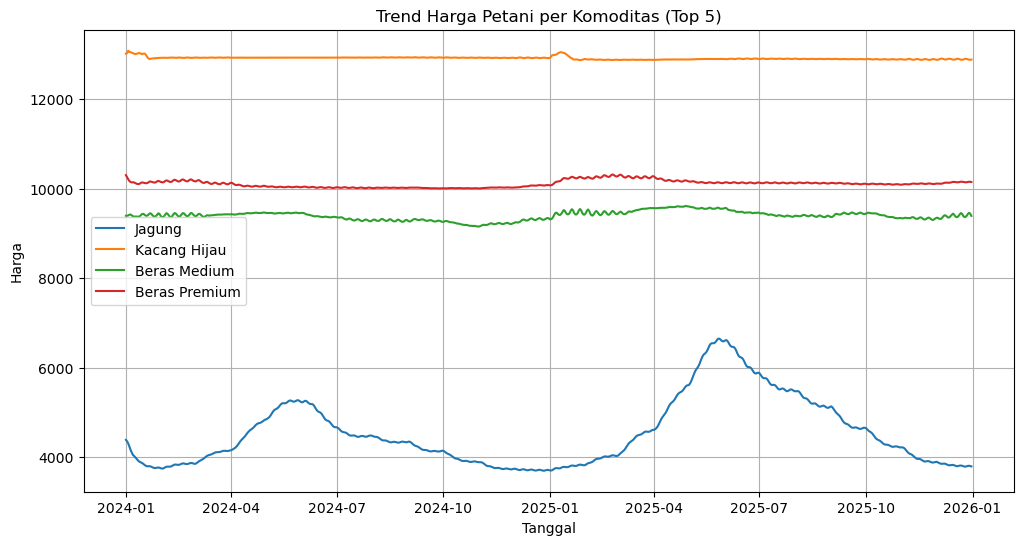

In [14]:
plt.figure(figsize=(12, 6))
top_commodities = df_x['Komoditi'].value_counts().head(5).index

for commodity in top_commodities:
    subset = df_x[df_x['Komoditi'] == commodity]
    sns.lineplot(
        x=subset['Tanggal'],
        y=subset['harga_petani_pred'],
        label=commodity
    )

plt.title('Trend Harga Petani per Komoditas (Top 5)')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
df_x['Komoditi'].unique()

array(['Jagung', 'Kacang Hijau', 'Beras Medium', 'Beras Premium'],
      dtype=object)

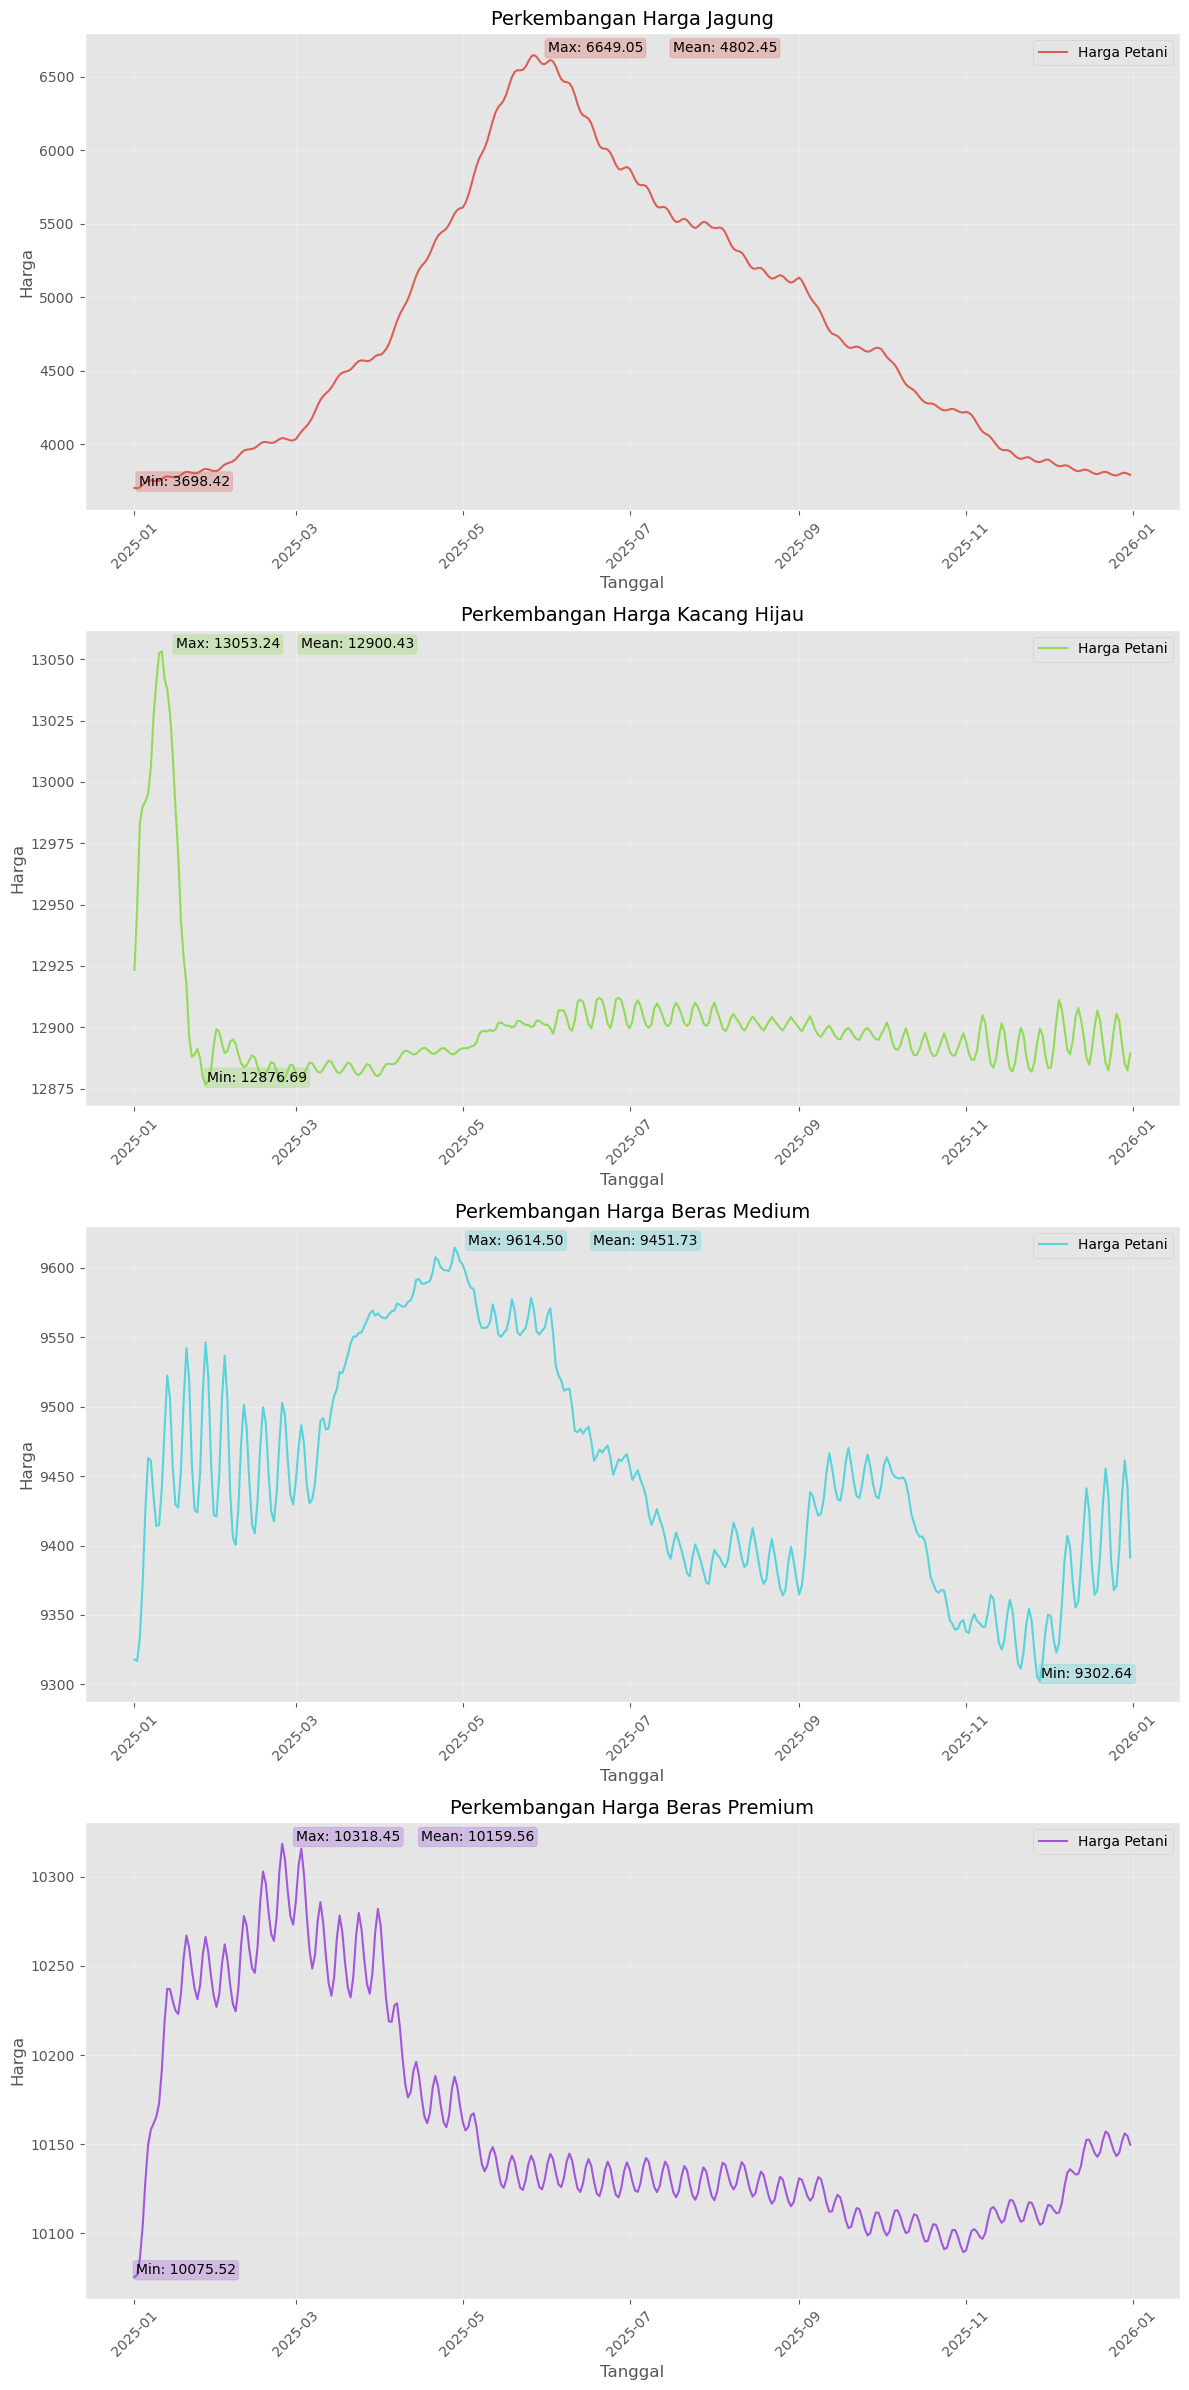

In [20]:

# Custom style
plt.style.use('ggplot')
colors = sns.color_palette("hls", 8)  # 8 warna berbeda untuk komoditas

# Daftar komoditas unik
komoditas_list = df_x['Komoditi'].unique()
df_x = df_x[df_x['Tanggal'].dt.year == 2025]

# Buat figure dengan subplot untuk setiap komoditas
fig, axes = plt.subplots(len(komoditas_list), 1, figsize=(12, 6*len(komoditas_list)))

# Plot per komoditas
for idx, komod in enumerate(komoditas_list):
    ax = axes[idx] if len(komoditas_list) > 1 else axes
    subset = df_x[df_x['Komoditi'] == komod]
    
    # Line plot
    sns.lineplot(data=subset, 
                 x='Tanggal', y='harga_petani_pred', 
                 label='Harga Petani', color=colors[idx*2], ax=ax)
    
    avg_harga_petani = subset['harga_petani_pred'].mean()
    avg_harga_pengecer = subset['harga_pengecer_pred'].mean()
    
    # Annotasi titik maksimum untuk Harga Petani
    max_petani = subset['harga_petani_pred'].max()
    min_petani = subset['harga_petani_pred'].min()
    max_date_petani = subset[subset['harga_petani_pred'] == max_petani]['Tanggal'].iloc[0]
    min_date_petani = subset[subset['harga_petani_pred'] == min_petani]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_petani:.2f}', 
                 xy=(max_date_petani, max_petani),
                 xytext=(10, 2), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', alpha=0.3, color=colors[idx*2]))
    ax.annotate(f'Min: {min_petani:.2f}', 
                 xy=(min_date_petani, min_petani),
                 xytext=(1, 2), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', alpha=0.3, color=colors[idx*2]))
    ax.annotate(f'Mean: {avg_harga_petani:.2f}', 
                 xy=(max_date_petani, max_petani),
                 xytext=(100, 2), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', alpha=0.3, color=colors[idx*2]))

    
    # Customisasi plot
    ax.set_title(f'Perkembangan Harga {komod}', fontsize=14)
    ax.set_xlabel('Tanggal', fontsize=12)
    ax.set_ylabel('Harga', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rotasi label tanggal
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

plt.tight_layout()
plt.show()


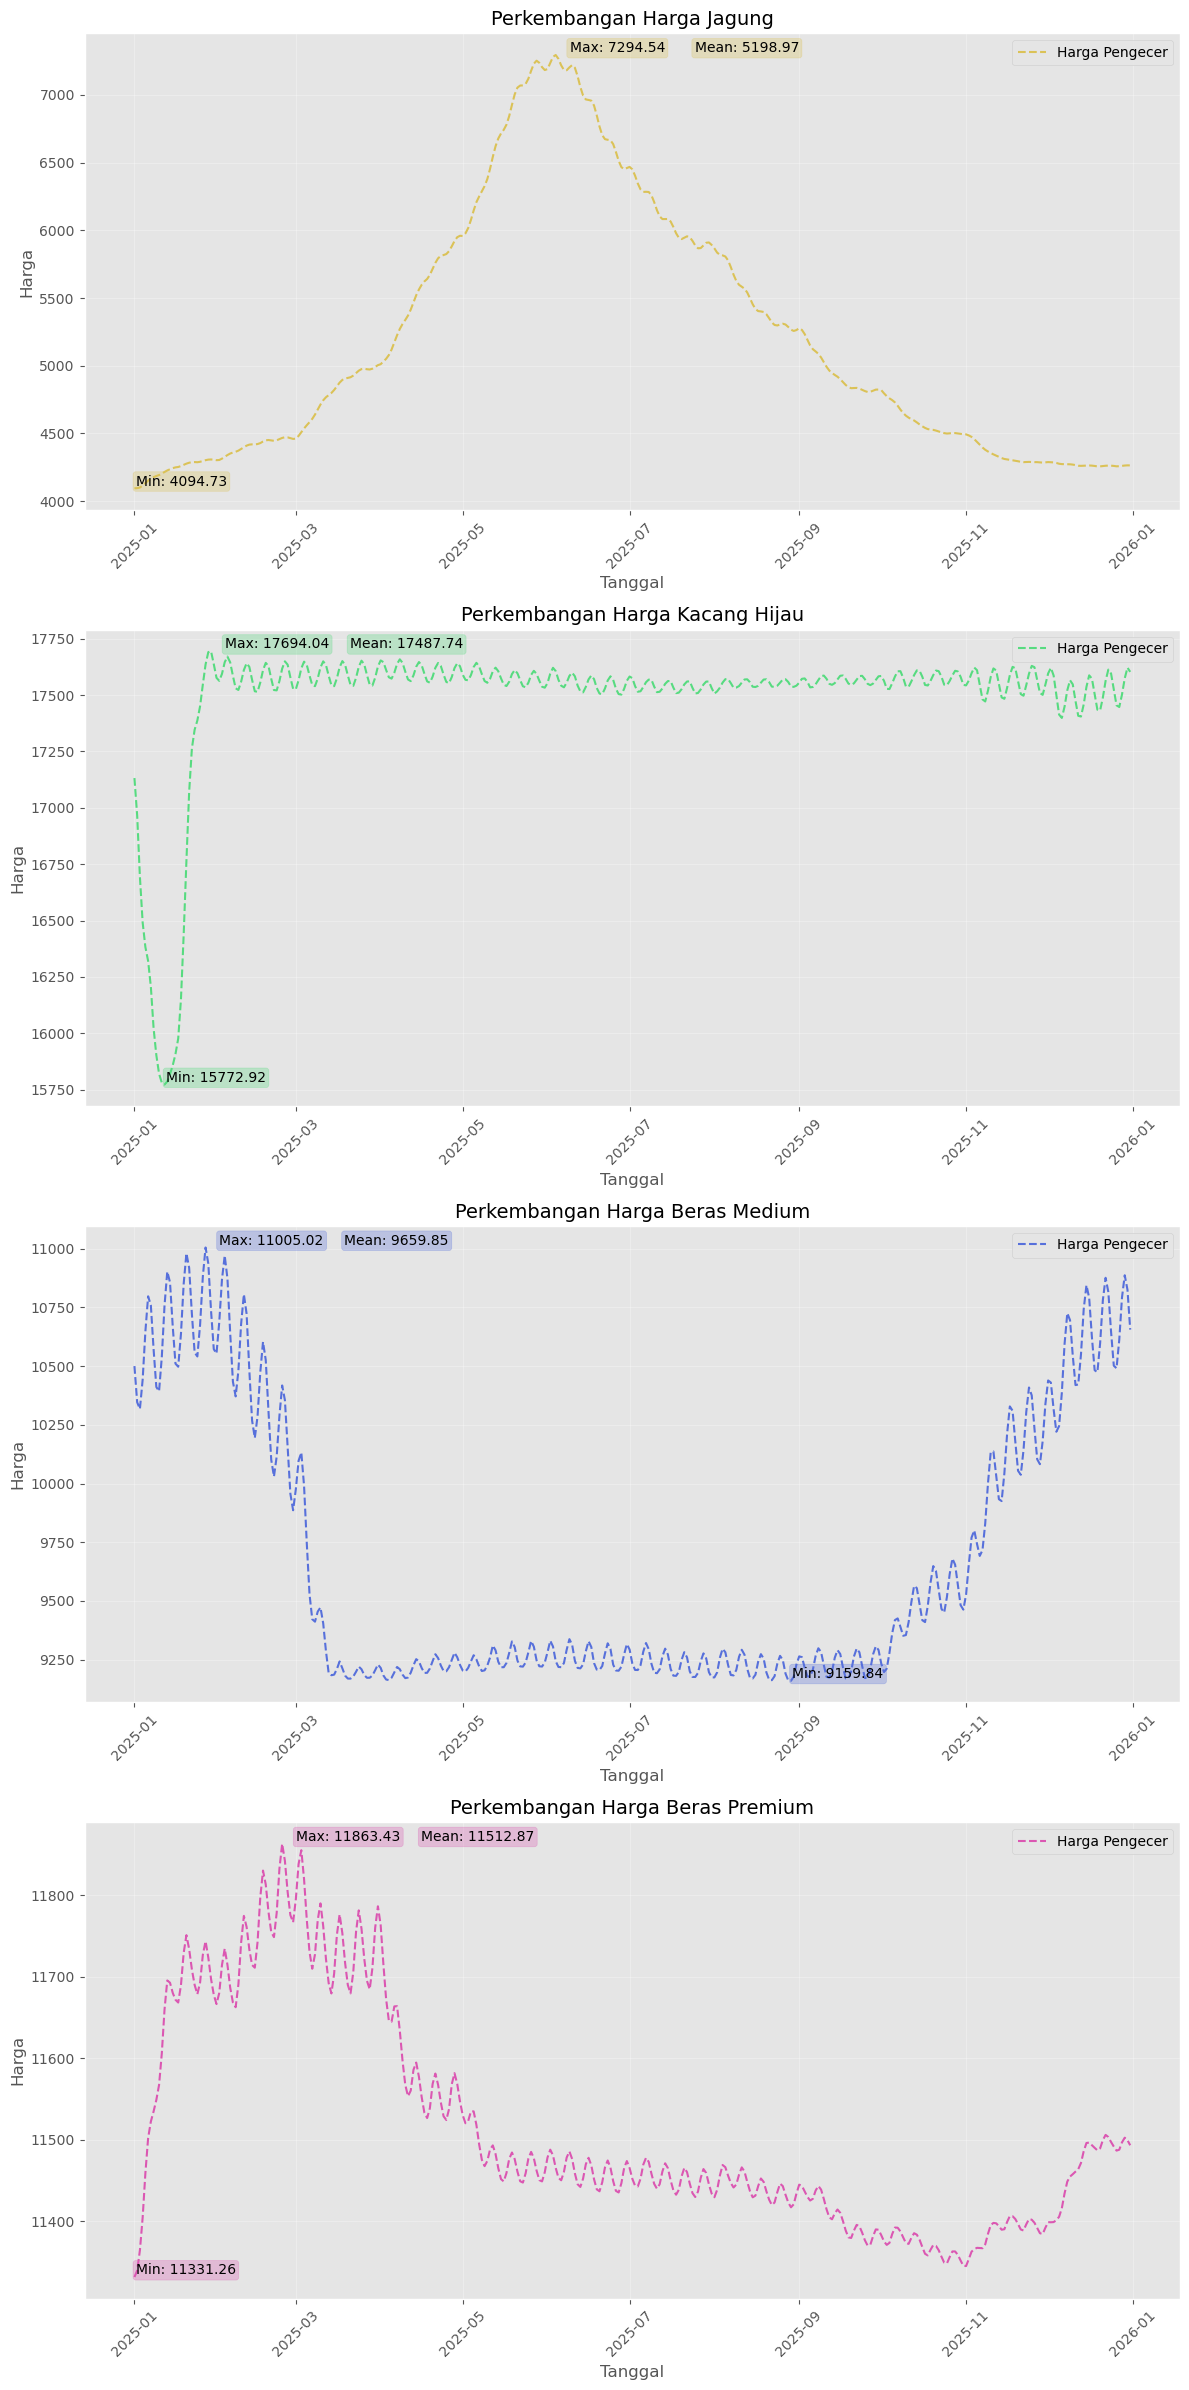

In [21]:
# Custom style
plt.style.use('ggplot')
colors = sns.color_palette("hls", 8)  # 8 warna berbeda untuk komoditas

# Daftar komoditas unik
komoditas_list = df_x['Komoditi'].unique()
df_x = df_x[df_x['Tanggal'].dt.year == 2025]

# Buat figure dengan subplot untuk setiap komoditas
fig, axes = plt.subplots(len(komoditas_list), 1, figsize=(12, 6*len(komoditas_list)))

# Plot per komoditas
for idx, komod in enumerate(komoditas_list):
    ax = axes[idx] if len(komoditas_list) > 1 else axes
    subset = df_x[df_x['Komoditi'] == komod]
    
    # Line plot
    sns.lineplot(data=subset, 
                 x='Tanggal', y='harga_pengecer_pred', 
                 label='Harga Pengecer', color=colors[idx*2+1], linestyle='--', ax=ax)
    
    avg_harga_petani = subset['harga_petani_pred'].mean()
    avg_harga_pengecer = subset['harga_pengecer_pred'].mean()
    
    
    
    # Annotasi titik maksimum untuk Harga Pengecer
    max_pengecer = subset['harga_pengecer_pred'].max()
    min_pengecer = subset['harga_pengecer_pred'].min()
    max_date_pengecer = subset[subset['harga_pengecer_pred'] == max_pengecer]['Tanggal'].iloc[0]
    min_date_pengecer = subset[subset['harga_pengecer_pred'] == min_pengecer]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_pengecer:.2f}', 
                 xy=(max_date_pengecer, max_pengecer),
                 xytext=(10, 2), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', alpha=0.3, color=colors[idx*2+1]))
    ax.annotate(f'Min: {min_pengecer:.2f}', 
                 xy=(min_date_pengecer, min_pengecer),
                 xytext=(1, 2), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', alpha=0.3, color=colors[idx*2+1]))
    ax.annotate(f'Mean: {avg_harga_pengecer:.2f}', 
                 xy=(max_date_pengecer, max_pengecer),
                 xytext=(100, 2), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', alpha=0.3, color=colors[idx*2+1]))
    
    # Customisasi plot
    ax.set_title(f'Perkembangan Harga {komod}', fontsize=14)
    ax.set_xlabel('Tanggal', fontsize=12)
    ax.set_ylabel('Harga', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rotasi label tanggal
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

plt.tight_layout()
plt.show()
